In [1]:
!ollama list

NAME                        ID              SIZE      MODIFIED    
llama3.1:latest             46e0c10c039e    4.9 GB    10 days ago    
embeddinggemma:latest       85462619ee72    621 MB    11 days ago    
mxbai-embed-large:latest    468836162de7    669 MB    11 days ago    
gemma:2b                    b50d6c999e59    1.7 GB    13 days ago    


In [2]:
from langchain_ollama import ChatOllama
llm_ollama = ChatOllama(model ="llama3.1")

# Tool calling 
sources/service from where we give context to LLM (API, internet, DB, ...)

In [3]:
from langchain_community.tools import WikipediaQueryRun
from langchain_community.utilities import WikipediaAPIWrapper

In [4]:
## WIKIPEDIA TOOL

api_wrapper = WikipediaAPIWrapper(top_k_results= 5, doc_content_chars_max=500)
wiki_tool = WikipediaQueryRun(api_wrapper= api_wrapper)

In [5]:
wiki_tool.run({"query" : "Generative AI"})

'Page: Generative artificial intelligence\nSummary: Generative artificial intelligence, also known as generative AI or GenAI, is a subfield of artificial intelligence that uses generative models to generate text, images, videos, audio, software code or other forms of data. These models learn the underlying patterns and structures of their training data, and use them to generate new data in response to input, which often takes the form of natural language prompts.\nThe prevalence of generative AI to'

In [6]:
## DuckDuckGoSearchRun
from langchain_community.tools import DuckDuckGoSearchRun
search = DuckDuckGoSearchRun()


In [7]:
search.invoke("What is latest update on Iran-Israel war?")

"9 minutes ago -A man was killed in central Israel after the latest round of missile fire from Iran, medics said on Thursday, raising the death toll in the country to 15 since the war began. Magen David Adom identified the victim as a “foreign worker” who ... 2 hours ago -As U.S. and Israeli air strikes pound Tehran, Iranian rescue workers are braving the risk of secondary attacks and say they are suffering trauma from the horror of pulling dead children from the rubble. ... The war on Iran has not delayed shipments of weapons to Taiwan or changed U.S. policy toward the island, officials from President Donald Trump's administration told members of Congress on Tuesday, despite the demands of the intense air campaign. 13 hours ago -Three Palestinians were also killed in a missile attack in the Israeli-occupied West Bank on Wednesday. ... Operations were suspended at the United Arab Emirates’ Habshan gas facility as authorities responded to two incidents of fallen debris after the success

In [8]:
## youtube search tool
from langchain_community.tools import YouTubeSearchTool
tool = YouTubeSearchTool()

In [9]:
tool.name

'youtube_search'

In [10]:
tool.description

'search for youtube videos associated with a person. the input to this tool should be a comma separated list, the first part contains a person name and the second a number that is the maximum number of video results to return aka num_results. the second part is optional'

In [11]:
tool.run("unacademy")

"['https://www.youtube.com/watch?v=TkIeokNRuwk&pp=ygUJdW5hY2FkZW15', 'https://www.youtube.com/watch?v=GeuZPf4fq1Y&pp=ygUJdW5hY2FkZW15']"

# Custom tool making

In [12]:
def multiply(a:int, b:int): ## Simple function
    return a*b
multiply(19,20)


380

In [13]:
from langchain.tools import tool

In [14]:
@tool
def multiply(a:int, b:int) -> int:
    """
    multiplies a and b
    """
    return a*b

In [15]:
multiply.invoke({"a":10, "b":30})

300

In [16]:
@tool
def get_word_lenght(word:str) -> int:
    """returns the length of the word"""
    return len(word)

get_word_lenght.invoke("hello world")

11

In [17]:
## tool for getting stock price

import yfinance as yf

In [18]:
@tool 
def get_stock_price(ticker:str) -> str:
    """
    this tool gets stock price using yfinance (YahooFinance)
    """

    try:
        stock = yf.Ticker(ticker)

        # Get last
        data = stock.history(period = "1d")

        if data.empty:
            return f"No data found for ticker '{ticker}'. Please check the symbol."
        
        lastest_cloes = data['Close'].iloc[-1]

        # detect currenccy
        currency = stock.info.get("currency","")
        symbol_map  = {
            "INR" : "₹",
            "USD" : "$",
            "EUR" : "€",
            "GBP" : " £"
        }
         
        symbol = symbol_map.get(currency,"")
        currency_text = currency if currency else ""

        if symbol:
            return (f"The last closing price of {ticker.upper()} was {symbol}{lastest_cloes:.2f}.")
        else:
            return (f"the last closing price of {ticker.upper()} was {lastest_cloes:.2f} {currency_text}.")
    except Exception as e:
        return f"An erro occors"
    

In [19]:
get_stock_price.invoke("AAPL") 

'The last closing price of AAPL was $249.94.'

In [20]:
get_stock_price.invoke("TCS.NS")

'The last closing price of TCS.NS was ₹2356.00.'

In [21]:
[get_stock_price, get_word_lenght]

[StructuredTool(name='get_stock_price', description='this tool gets stock price using yfinance (YahooFinance)', args_schema=<class 'langchain_core.utils.pydantic.get_stock_price'>, func=<function get_stock_price at 0x000002A767F71440>),
 StructuredTool(name='get_word_lenght', description='returns the length of the word', args_schema=<class 'langchain_core.utils.pydantic.get_word_lenght'>, func=<function get_word_lenght at 0x000002A74D494A40>)]

In [22]:
tools = [get_word_lenght, get_stock_price]
ollama_llm_with_tools = llm_ollama.bind_tools(tools)

In [23]:
result = ollama_llm_with_tools.invoke("what is the stock price of TCS.NS?")  
## Will be empty as llm now directs the result to call a tool instead of answering directly

In [24]:
result.content

''

In [25]:
result.tool_calls ## the associated tool with the input query

[{'name': 'get_stock_price',
  'args': {'ticker': 'TCS.NS'},
  'id': '6ca327e2-a5ab-4f17-8344-ba6baee11139',
  'type': 'tool_call'}]

In [26]:
from langchain_core.messages import HumanMessage, AIMessage
from langgraph.graph import MessagesState, StateGraph, END, START
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition

In [27]:
def function_1():
    pass

In [28]:
tools

[StructuredTool(name='get_word_lenght', description='returns the length of the word', args_schema=<class 'langchain_core.utils.pydantic.get_word_lenght'>, func=<function get_word_lenght at 0x000002A74D494A40>),
 StructuredTool(name='get_stock_price', description='this tool gets stock price using yfinance (YahooFinance)', args_schema=<class 'langchain_core.utils.pydantic.get_stock_price'>, func=<function get_stock_price at 0x000002A767F71440>)]

In [29]:
function_2 = ToolNode(tools)

In [30]:
workflow = StateGraph(MessagesState)

In [31]:
workflow.add_node("llm_ollama", function_1)

In [32]:
workflow.add_node("tools", function_2)

In [33]:
workflow.add_edge(START, "llm_ollama")

In [34]:
workflow.add_conditional_edges(
    "llm_ollama",
    tools_condition,
)

In [35]:
workflow.add_edge("tools",'llm_ollama')

In [36]:
app = workflow.compile()

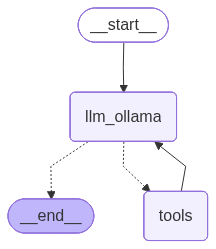

In [37]:
from IPython.display import Image, display
display(Image(app.get_graph(xray=True).draw_mermaid_png()))